In [45]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf
from EFC_learningfMRI.util import add_behav_pair_diff, ttest_im_sess
from EFC_learningfMRI.vis import plot_im_sess

In [65]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
dist  = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist  = dist[(dist.Hem==H) & (dist.chord.isin(['trained', 'untrained']))]
measX = ['ET', 'MD', 'force_abs', 'force_der', 'force_der_peak']
force = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, f'force.success.tsv'), sep='\t')
diff  = add_behav_pair_diff(dist, measures=measX, behav=force)

diff = diff[diff.sn!=117]

diff[['crossnobis_res', 'theta_res']] = np.nan
for sn in diff.sn.unique():
    diff_s = diff[diff.sn == sn]
    X      = np.c_[diff_s[['MD', 'force_abs']].to_numpy(), np.ones(diff_s.shape[0])]
    Y      = diff_s[['crossnobis', 'theta']].to_numpy()
    diff.loc[diff.sn == sn, ['crossnobis_res', 'theta_res']] = Y - X @ (np.linalg.pinv(X) @ Y)

diff_chord_sess = diff.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

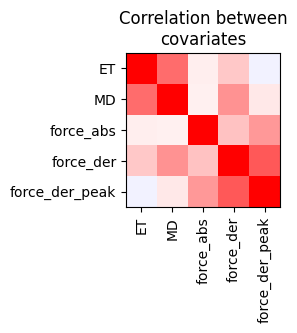

In [54]:
corrX = diff[measX].corr()

fig, ax = plt.subplots(figsize=(2, 2))

ax.imshow(corrX, vmin=-1, vmax=1, cmap='bwr')
ax.set_xticks(np.arange(len(measX)))
ax.set_yticks(np.arange(len(measX)))
ax.set_xticklabels(measX, rotation=90)
ax.set_yticklabels(measX)

ax.set_title('Correlation between\ncovariates')

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.670652   12  0.515143  [-0.022, 0.012]   SMA        3
3  -0.390954   12  0.702684  [-0.021, 0.014]   PMd        3
6  -1.568458   12  0.142753  [-0.041, 0.007]   PMv        3
9  -0.280874   12  0.783591  [-0.054, 0.041]    M1        3
12 -0.570027   12  0.579176   [-0.04, 0.023]    S1        3
15 -1.032929   12  0.322006  [-0.053, 0.019]  SPLa        3
18 -0.649336   12  0.528354  [-0.051, 0.027]  SPLp        3
7  -0.379392   12  0.711025  [-0.045, 0.031]   PMv        9
13  0.769318   12  0.456581  [-0.027, 0.057]    S1        9
10  0.623455   12  0.544654  [-0.035, 0.063]    M1        9
4  -0.624896   12  0.543739   [-0.037, 0.02]   PMd        9
1  -0.314217   12  0.758752   [-0.03, 0.023]   SMA        9
16 -0.232728   12  0.819895  [-0.036, 0.029]  SPLa        9
19 -0.111949   12  0.912715  [-0.038, 0.034]  SPLp        9
5   0.409752   12  0.689208  [-0.011, 0.016]   PMd       23
2  -0.655332   12  0.524619   [-0.018, 0

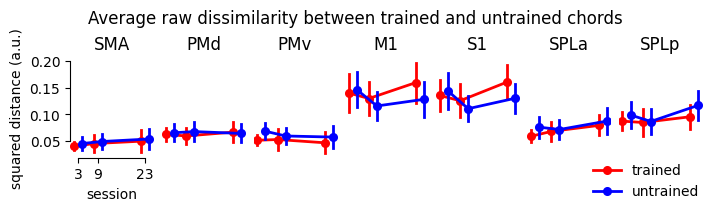

In [59]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average raw dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.807770   12  0.434944   [-0.023, 0.01]   SMA        3
3  -0.711697   12  0.490257  [-0.016, 0.008]   PMd        3
6  -1.637756   12  0.127409  [-0.042, 0.006]   PMv        3
9  -0.328970   12  0.747849  [-0.053, 0.039]    M1        3
12 -0.655218   12  0.524689   [-0.04, 0.021]    S1        3
15 -1.286294   12  0.222604  [-0.048, 0.012]  SPLa        3
18 -0.829943   12  0.422775   [-0.045, 0.02]  SPLp        3
7  -0.596775   12  0.561748  [-0.044, 0.025]   PMv        9
13  0.625035   12  0.543651   [-0.03, 0.054]    S1        9
10  0.485216   12  0.636261  [-0.039, 0.061]    M1        9
4  -0.923216   12  0.374086  [-0.037, 0.015]   PMd        9
1  -0.642256   12  0.532785  [-0.029, 0.016]   SMA        9
16 -0.475997   12  0.642625  [-0.035, 0.023]  SPLa        9
19 -0.320770   12  0.753902  [-0.036, 0.027]  SPLp        9
5   0.991544   12  0.340993  [-0.009, 0.024]   PMd       23
2   0.136153   12  0.893958  [-0.013, 0.

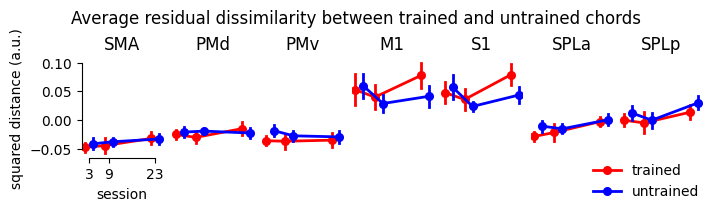

In [66]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('squared distance (a.u.)')

fig.suptitle('Average residual dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='crossnobis_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0   0.008993   12  0.992972   [-0.06, 0.061]   SMA        3
3   0.126664   12  0.901304  [-0.045, 0.051]   PMd        3
6  -1.080221   12  0.301276  [-0.078, 0.026]   PMv        3
9  -0.253116   12  0.804463  [-0.065, 0.051]    M1        3
12 -0.008567   12  0.993305   [-0.05, 0.049]    S1        3
15 -0.359660   12  0.725351    [-0.07, 0.05]  SPLa        3
18 -0.486950   12  0.635067  [-0.061, 0.038]  SPLp        3
7  -0.380399   12  0.710297  [-0.068, 0.048]   PMv        9
13  0.873153   12  0.399715  [-0.031, 0.072]    S1        9
10  0.206024   12  0.840226  [-0.042, 0.051]    M1        9
4   0.081016   12  0.936765  [-0.039, 0.042]   PMd        9
1  -1.600568   12  0.135454  [-0.073, 0.011]   SMA        9
16  0.444396   12  0.664665  [-0.037, 0.056]  SPLa        9
19  0.162901   12  0.873307  [-0.031, 0.036]  SPLp        9
5   1.226202   12  0.243641  [-0.015, 0.055]   PMd       23
2  -0.265849   12  0.794868   [-0.077, 0

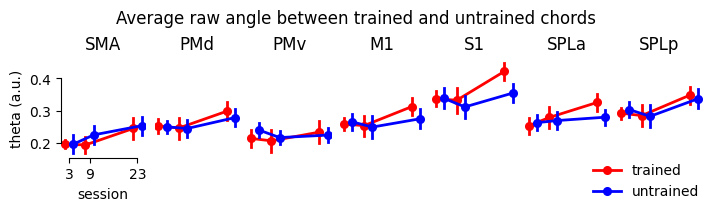

In [61]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('theta (a.u.)')

fig.suptitle('Average raw angle between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()

           T  dof     p_val             CI95   roi  session
0  -0.028972   12  0.977363  [-0.058, 0.056]   SMA        3
3   0.094557   12  0.926227  [-0.039, 0.043]   PMd        3
6  -1.195327   12  0.255048  [-0.076, 0.022]   PMv        3
9  -0.312948   12  0.759692  [-0.062, 0.046]    M1        3
12 -0.057770   12  0.954883  [-0.046, 0.044]    S1        3
15 -0.453737   12  0.658114  [-0.064, 0.042]  SPLa        3
18 -0.626656   12  0.542623   [-0.054, 0.03]  SPLp        3
7  -0.461247   12  0.652870  [-0.071, 0.046]   PMv        9
13  0.760878   12  0.461420  [-0.034, 0.071]    S1        9
10  0.095063   12  0.925834  [-0.048, 0.052]    M1        9
4  -0.037152   12  0.970975  [-0.043, 0.042]   PMd        9
1  -1.827135   12  0.092641  [-0.073, 0.006]   SMA        9
16  0.353574   12  0.729793  [-0.037, 0.052]  SPLa        9
19  0.018504   12  0.985541  [-0.031, 0.032]  SPLp        9
5   1.555206   12  0.145864    [-0.01, 0.06]   PMd       23
2  -0.100684   12  0.921464  [-0.072, 0.

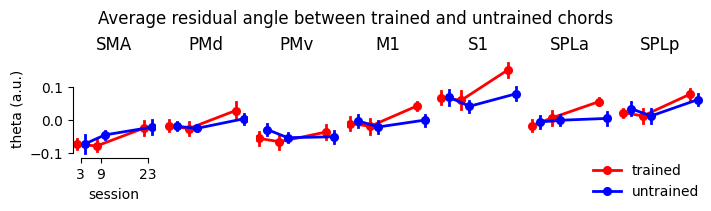

In [68]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, diff_chord_sess, rois, y='theta_res', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('theta (a.u.)')

fig.suptitle('Average residual angle between trained and untrained chords')

ttest = ttest_im_sess(diff_chord_sess, rois, y='theta_res', x='session', hue='chord', hue_order=hue_order)
ttest['regionname'] = pd.Categorical(ttest.roi, categories=gl.rois[atlas], ordered=True)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()